In [ ]:
import torch

print(torch.cuda.is_available())

True


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import zipfile

zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/dataset"))

['dataset']


In [ ]:
print(os.listdir("/content/dataset/dataset"))

['test', 'val', 'train']


In [ ]:
print(os.listdir("/content/dataset/dataset/train"))

['normal', 'potholes']


In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torchvision

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(
    "/content/dataset/dataset/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "/content/dataset/dataset/val",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    "/content/dataset/dataset/test",
    transform=transform
)

In [ ]:
print("Classes:", train_dataset.classes)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Test Images:", len(test_dataset))

Classes: ['normal', 'potholes']
Training Images: 544
Validation Images: 67
Test Images: 70


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))

print("Image Batch Shape:", images.shape)
print("Labels Shape:", labels.shape)

Image Batch Shape: torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])


In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


In [ ]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

print(device)

cuda


In [ ]:
print(labels[:10])
print(device)

tensor([1, 1, 1, 0, 0, 1, 0, 0, 0, 1])
cuda


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )


Epoch 1/5, Loss: 0.3110
Epoch 2/5, Loss: 0.0620
Epoch 3/5, Loss: 0.0410
Epoch 4/5, Loss: 0.0216
Epoch 5/5, Loss: 0.0439


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 82.86%


In [ ]:
torch.save(
    model.state_dict(),
    "pothole_model.pth"
)

print("Model Saved!")

Model Saved!


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import torch
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

model.load_state_dict(
    torch.load("pothole_model.pth", map_location=device)
)

model = model.to(device)

model.eval()

print("Model Loaded Successfully!")

Model Loaded Successfully!


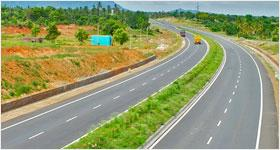

In [ ]:
from PIL import Image

image = Image.open("/content/1.jpg")
image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image_tensor = transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

print(image_tensor.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
with torch.no_grad():

    outputs = model(image_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    confidence, predicted = torch.max(
        probabilities,
        1
    )

classes = ['normal', 'potholes']

print(
    f"Prediction: {classes[predicted.item()]}"
)

print(
    f"Confidence: {confidence.item()*100:.2f}%"
)

Prediction: normal
Confidence: 100.00%
